In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
# Create a date range starting from '2023-01-01', for 15 days
start_date = '2023-01-01'
date_range = pd.date_range(start_date, periods=15, freq='D')

# Generate random data for those dates
data = {'Date': date_range, 'Value': np.random.randint(1, 10, size=len(date_range))}
df = pd.DataFrame(data)

# Group by week and sum
grouped_df = df.groupby([pd.Grouper(key='Date', freq='W')]).sum()

print("Original DataFrame:")
print(df)
print("\nGrouped DataFrame:")
print(grouped_df)

In [28]:
with open(r'C:\Users\olooney\Desktop\projects\oranlooney.com\static\games\font-wars\resources\words.txt') as fin:
    words = fin.read()

In [31]:
words = [ w.strip() for w in words.split('\n') if w.strip() ]

In [33]:
lengths = [ len(w) for w in words ]

In [34]:
from collections import Counter

In [37]:
counts = Counter(lengths)

In [36]:
import pandas as pd

In [44]:
df = pd.DataFrame({ "lengths": counts.keys(), "count": counts.values() })

In [45]:
df.sort_values('lengths', inplace=True)
df.reset_index(inplace=True, drop=True)
df

,lengths,count
0,1,2
1,2,25
2,3,133
3,4,398
4,5,388
5,6,459
6,7,414
7,8,370
8,9,339
9,10,215


Text(0.5, 1.0, 'Your Title Here')

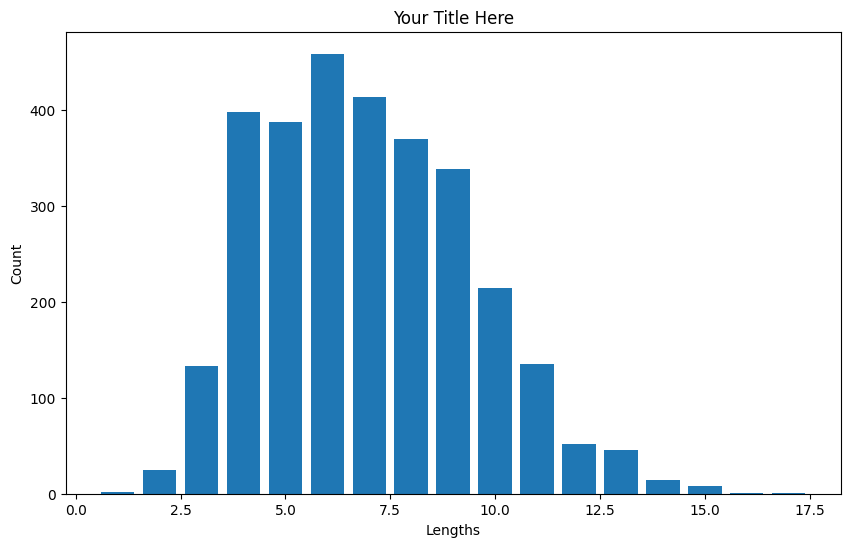

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df['lengths'], df['count'], width=0.8)  # Adjust width as needed
plt.xlabel('Lengths')
plt.ylabel('Count')
plt.title('Your Title Here')

In [57]:
def read_and_convert(file_name):
    lengths = []
    with open(file_name, 'r') as f:
        for line in f:
            word, _ = line.strip().split('\t')
            lengths.append(len(word))
    
    df = pd.DataFrame(lengths, columns=['lengths'])
    df = df['lengths'].value_counts().reset_index()
    df.columns = ['lengths', 'count']
    df = df.sort_values('lengths').reset_index(drop=True)
    
    return df

# Usage
df2 = read_and_convert(r"C:\Users\olooney\Dropbox\code\python\playfair\count_1w.txt")
df2

,lengths,count
0,1,26
1,2,200
2,3,354
3,4,657
4,5,752
5,6,768
6,7,736
7,8,557
8,9,405
9,10,258


In [66]:
# Normalize counts to create empirical CDFs
df['ecdf'] = df['count'].cumsum() / df['count'].sum()
df2['ecdf'] = df2['count'].cumsum() / df2['count'].sum()

df['normcount'] = df['count'] / df['count'].sum()
df2['normcount'] = df2['count'] / df2['count'].sum()

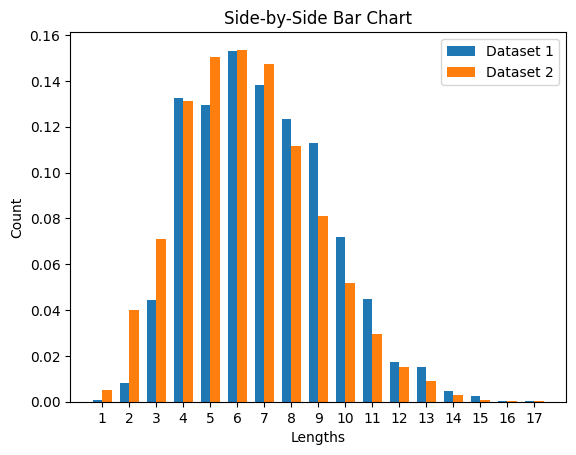

In [67]:
# Bar chart
barWidth = 0.35
fig, ax = plt.subplots()
bar1 = np.arange(len(df['lengths']))
bar2 = [x + barWidth for x in bar1]

ax.bar(bar1, df['normcount'], width=barWidth, label='Dataset 1')
ax.bar(bar2, df2['normcount'], width=barWidth, label='Dataset 2')
ax.set_xlabel('Lengths')
ax.set_ylabel('Count')
ax.set_title('Side-by-Side Bar Chart')
ax.set_xticks([x + barWidth / 2 for x in range(len(df['lengths']))])
ax.set_xticklabels(df['lengths'])
ax.legend()

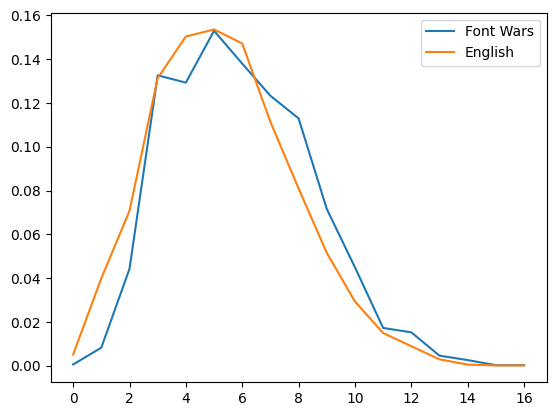

In [69]:
plt.plot(df['normcount'], label='Font Wars')
plt.plot(df2['normcount'], label='English')
plt.legend()

KS Statistic: 0.058823529411764705
P-value: 1.0


In [89]:
merged_df = pd.merge(df, df2, on='lengths', how='outer', suffixes=('', '2'))
merged_df.fillna(0, inplace=True)
merged_df['ecdf'] = merged_df['count'].cumsum() / merged_df['count'].sum()
merged_df['ecdf2'] = merged_df['count2'].cumsum() / merged_df['count2'].sum()
merged_df['normcount'] = merged_df['count'] / merged_df['count'].sum()
merged_df['normcount2'] = merged_df['count2'] / merged_df['count2'].sum()
print(str(merged_df))

    lengths  count      ecdf  normcount  count2   ecdf2  normcount2
0         1    2.0  0.000667   0.000667    26.0  0.0052      0.0052
1         2   25.0  0.009000   0.008333   200.0  0.0452      0.0400
2         3  133.0  0.053333   0.044333   354.0  0.1160      0.0708
3         4  398.0  0.186000   0.132667   657.0  0.2474      0.1314
4         5  388.0  0.315333   0.129333   752.0  0.3978      0.1504
5         6  459.0  0.468333   0.153000   768.0  0.5514      0.1536
6         7  414.0  0.606333   0.138000   736.0  0.6986      0.1472
7         8  370.0  0.729667   0.123333   557.0  0.8100      0.1114
8         9  339.0  0.842667   0.113000   405.0  0.8910      0.0810
9        10  215.0  0.914333   0.071667   258.0  0.9426      0.0516
10       11  135.0  0.959333   0.045000   147.0  0.9720      0.0294
11       12   52.0  0.976667   0.017333    75.0  0.9870      0.0150
12       13   46.0  0.992000   0.015333    45.0  0.9960      0.0090
13       14   14.0  0.996667   0.004667    15.0 

KS Statistic: 0.09226666666666666
P-value: 2.477224775201457e-14


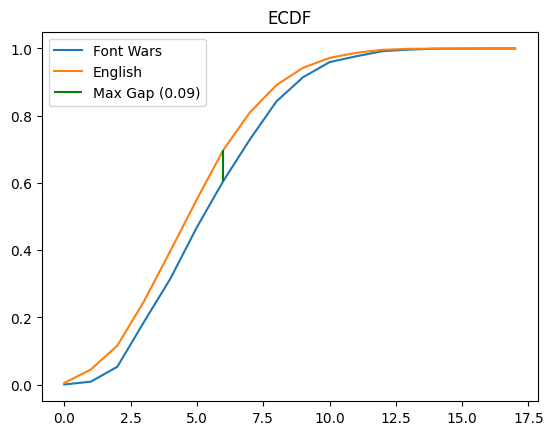

In [100]:
plt.title("ECDF")
plt.plot(merged_df['ecdf'], label='Font Wars')
plt.plot(merged_df['ecdf2'], label='English')

gap = np.abs(merged_df['ecdf'] - merged_df['ecdf2'])
index = np.argmax(gap)
max_gap = gap[index]
plt.vlines(index, merged_df['ecdf'][index], merged_df['ecdf2'][index], color='green', label=f'Max Gap ({max_gap:0.2f})')
plt.legend()

raw_data1 = np.repeat(merged_df['lengths'], merged_df['count'].astype(int))
raw_data2 = np.repeat(merged_df['lengths'], merged_df['count2'].astype(int))

ks_statistic, p_value = stats.ks_2samp(raw_data1, raw_data2)

print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

In [94]:
ks = stats.ks_2samp(merged_df['ecdf'], merged_df['ecdf2'])

In [97]:
pvalue = (statistic * np.sqrt((n1 * n2) / (n1 + n2)))


1.0

In [102]:
from scipy.stats import kstwobign

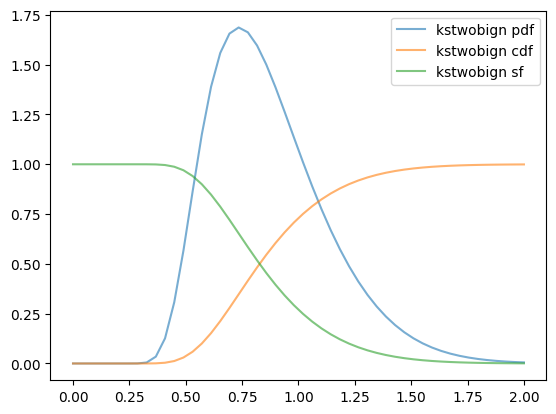

In [110]:
x = np.linspace(0, 2)
plt.plot(x, kstwobign.pdf(x), alpha=0.6, label='kstwobign pdf')
plt.plot(x, kstwobign.cdf(x), alpha=0.6, label='kstwobign cdf')
plt.plot(x, kstwobign.sf(x), alpha=0.6, label='kstwobign sf')
plt.legend()